In [121]:
import pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re
import hdbscan
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


N_CLUSTER = 8

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

In [4]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [106]:
def advanced_clean_text(text):
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)

In [6]:
combined_details_df = pd.read_csv("../data/combined_details.csv")
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_53701/2128574053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [94]:
filtered_df = combined_details_df[(combined_details_df['tags']).str.lower().str.contains('landmark', na=False)]

In [95]:
filtered_df[['name', 'tags']]

,name,tags
5,Doi Chang Mub Arboretum,"Points of Interest & Landmarks, Lookouts"
7,Golden Triangle,Points of Interest & Landmarks
17,Wat Lai,Points of Interest & Landmarks
26,Wat Sao Thong Thong,"Points of Interest & Landmarks, Sacred & Relig..."
28,Kraison Siharat Hall,Points of Interest & Landmarks
...,...,...
1734,Wat Traphang Thong,"Points of Interest & Landmarks, Sacred & Relig..."
1736,Chiang Chom Temple (Wat Chedi Plong Pagoda),Points of Interest & Landmarks
1742,Ayutthaya Historical Park,"Historic Sites, Ancient Ruins, Architectural B..."
1745,Wat Wichian Bamrung,"Sacred & Religious Sites, Points of Interest &..."


In [96]:
filtered_df['cleaned_tags'] = filtered_df['tags'].apply(advanced_clean_text)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_53701/796046214.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [97]:
filtered_df[['name', 'tags', 'cleaned_tags']].iloc[:1]

,name,tags,cleaned_tags
5,Doi Chang Mub Arboretum,"Points of Interest & Landmarks, Lookouts",lookout


In [113]:
combined_details_df['cleaned_tags'] = combined_details_df['tags'].apply(advanced_clean_text)

In [114]:
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

In [115]:
combined_details_df['cleaned_tags']

0               history museum specialty museum
1                                      bar club
2                              sacred religious
3                                     boat tour
4                                    body water
                         ...                   
1761                                      beach
1762                                     bridge
1763    sacred religious architectural building
1764                                      beach
1765                                    lookout
Name: cleaned_tags, Length: 1766, dtype: object

In [116]:
sentences = combined_details_df['cleaned_tags'].str.split()
sentences

0               [history, museum, specialty, museum]
1                                        [bar, club]
2                                [sacred, religious]
3                                       [boat, tour]
4                                      [body, water]
                            ...                     
1761                                         [beach]
1762                                        [bridge]
1763    [sacred, religious, architectural, building]
1764                                         [beach]
1765                                       [lookout]
Name: cleaned_tags, Length: 1766, dtype: object

In [117]:
sentences = combined_details_df['cleaned_tags'].str.split()  # Tokenized tags
word2vec_model = Word2Vec(sentences, vector_size=CONST_VECTOR_SIZE, window=CONST_DIM_WINDOWS, min_count=1, workers=4)

# Compute TF-IDF
tag_texts = [' '.join(tag) for tag in sentences]
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(tag_texts)
tfidf_vocab = tfidf_vectorizer.vocabulary_

In [118]:
def get_tag_vector(tag):
    vectors = []
    for word in tag:
        if word in word2vec_model.wv and word in tfidf_vocab:
            tfidf_weight = tfidf_matrix[0, tfidf_vocab[word]]  # Get TF-IDF weight for the word
            word_vector = word2vec_model.wv[word] * tfidf_weight  # Multiply Word2Vec by TF-IDF weight
            vectors.append(word_vector)
    if vectors:
        return np.mean(vectors, axis=0)  # Average the weighted Word2Vec embeddings
    else:
        return np.zeros(word2vec_model.vector_size)  # Return a zero vector if no valid words

# Generate tag embeddings
tag_embeddings = np.array([get_tag_vector(tag) for tag in sentences])

In [132]:
def optimize_hdbscan(data, min_cluster_sizes=[5, 10, 15], min_samples_values=[1, 5, 10]):
    """
    Optimizes HDBSCAN by varying `min_cluster_size` and `min_samples` using cosine distance.
    Evaluates clustering quality using Silhouette Score and Davies-Bouldin Index.
    """
    # Step 1: Normalize embeddings and compute cosine similarity
    normalized_data = normalize(data, axis=1)  # Normalize to unit vectors
    cosine_sim_matrix = cosine_similarity(normalized_data)  # Shape: (n_samples, n_samples)
    cosine_distances = np.maximum(1 - cosine_sim_matrix, 0)  # Ensure non-negative values

    # Step 2: Fix diagonal values to ensure they are 0
    np.fill_diagonal(cosine_distances, 0)

    best_params = {"min_cluster_size": None, "min_samples": None}
    best_silhouette = -1
    best_dbi = float('inf')
    results = []

    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_values:
            # Step 3: Apply HDBSCAN with precomputed distance
            clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                        min_samples=min_samples,
                                        metric='euclidean')
            labels = clusterer.fit_predict(cosine_distances)

            # Step 4: Ensure at least 2 clusters exist
            if len(set(labels)) > 1:
                # Silhouette score requires data to match cluster labels
                silhouette_avg = silhouette_score(cosine_distances, labels, metric='euclidean')
                dbi_score = davies_bouldin_score(data, labels)
                results.append((min_cluster_size, min_samples, silhouette_avg, dbi_score))

                if silhouette_avg > best_silhouette or (silhouette_avg == best_silhouette and dbi_score < best_dbi):
                    best_silhouette = silhouette_avg
                    best_dbi = dbi_score
                    best_params["min_cluster_size"] = min_cluster_size
                    best_params["min_samples"] = min_samples

    # Step 5: Plot Silhouette Scores
    plt.figure(figsize=(10, 6))
    for min_cluster_size, min_samples, silhouette, _ in results:
        plt.scatter(min_cluster_size, min_samples, c=silhouette, cmap="viridis", s=100, label=f"Score: {silhouette:.4f}")
    plt.colorbar(label="Silhouette Score")
    plt.xlabel("min_cluster_size")
    plt.ylabel("min_samples")
    plt.title("Silhouette Scores for HDBSCAN")
    plt.show()

    print(f"Best Parameters: {best_params}, Best Silhouette Score: {best_silhouette:.4f}, Best DBI: {best_dbi:.4f}")
    return best_params

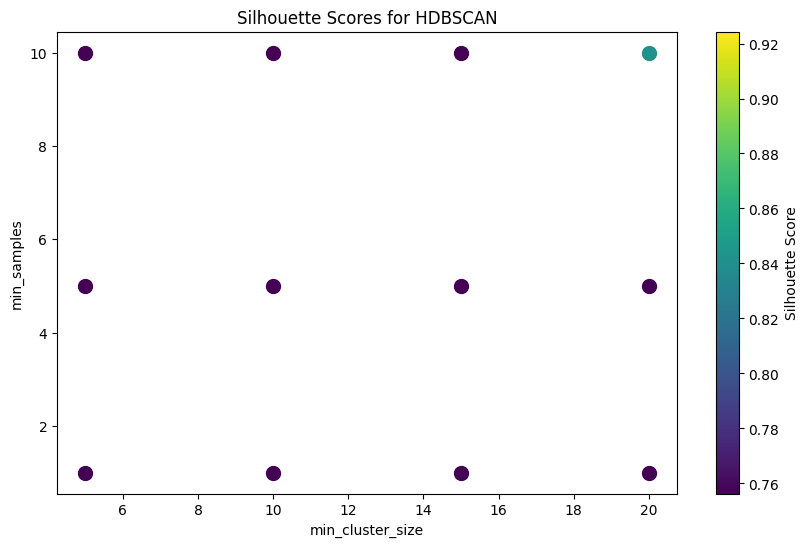

Best Parameters: {'min_cluster_size': 5, 'min_samples': 10}, Best Silhouette Score: 0.8424, Best DBI: 0.7716


In [133]:
BEST_OPTIMIZE_HDBSCAN = optimize_hdbscan(tag_embeddings, 
                                       min_cluster_sizes=[5, 10, 15, 20], 
                                       min_samples_values=[1, 5, 10])

In [124]:
def apply_hdbscan(data, min_cluster_size, min_samples):
    """Applies HDBSCAN with optimized parameters and evaluates clustering quality."""

    # Convert Cosine Similarity to Cosine Distance
    cosine_sim_matrix = cosine_similarity(data)
    cosine_distances = 1 - cosine_sim_matrix  # Convert similarity to distance
    
    # Normalize distances to prevent negative values
    scaler = MinMaxScaler()
    cosine_distances = scaler.fit_transform(cosine_distances)

    # Apply HDBSCAN with optimized parameters
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, 
                                min_samples=min_samples, 
                                metric='precomputed')
    labels = clusterer.fit_predict(cosine_distances)

    # Compute Evaluation Metrics
    unique_labels = set(labels) - {-1}  # Exclude noise (-1)
    
    if len(unique_labels) > 1:
        silhouette_avg = silhouette_score(cosine_distances, labels)
        dbi_score = davies_bouldin_score(cosine_distances, labels)
    else:
        silhouette_avg = -1  # Invalid clustering case
        dbi_score = -1

    print(f"✅ Silhouette Score: {silhouette_avg:.4f}")
    print(f"✅ Davies-Bouldin Index: {dbi_score:.4f}")
    print(f"✅ Number of clusters (excluding noise): {len(unique_labels)}")
    
    return labels

In [125]:
optimized_labels = apply_hdbscan(tag_embeddings, 
                                 min_cluster_size=BEST_OPTIMIZE_HDBSCAN["min_cluster_size"], 
                                 min_samples=BEST_OPTIMIZE_HDBSCAN["min_samples"])

✅ Silhouette Score: 0.9751
✅ Davies-Bouldin Index: 0.1109
✅ Number of clusters (excluding noise): 6


In [126]:
if len(set(optimized_labels)) > 1:
    silhouette_avg = silhouette_score(tag_embeddings, optimized_labels)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
else:
    print("Clustering resulted in fewer than 2 clusters.")

# Print Results
for tag, label in zip(combined_details_df['tags'], optimized_labels):
    print(f"Tag: '{tag}' is in Cluster: {label}")

Silhouette Score: 0.9770
Tag: 'History Museums, Specialty Museums' is in Cluster: 1
Tag: 'Bars & Clubs' is in Cluster: 1
Tag: 'Sacred & Religious Sites' is in Cluster: 1
Tag: 'Boat Tours' is in Cluster: 1
Tag: 'Bodies of Water' is in Cluster: 1
Tag: 'Points of Interest & Landmarks, Lookouts' is in Cluster: 1
Tag: 'Gardens' is in Cluster: 1
Tag: 'Points of Interest & Landmarks' is in Cluster: 1
Tag: 'Sightseeing Tours' is in Cluster: 1
Tag: 'Hot Springs & Geysers' is in Cluster: 1
Tag: 'National Parks, Parks' is in Cluster: 1
Tag: 'Flea & Street Markets' is in Cluster: 1
Tag: 'Shopping Malls' is in Cluster: 1
Tag: 'Specialty Museums' is in Cluster: 3
Tag: 'Historic Sites' is in Cluster: 1
Tag: 'Historic Sites, Ancient Ruins' is in Cluster: 1
Tag: 'Zoos' is in Cluster: 1
Tag: 'Points of Interest & Landmarks' is in Cluster: 1
Tag: 'Performances' is in Cluster: 1
Tag: 'Sacred & Religious Sites' is in Cluster: 1
Tag: 'Sacred & Religious Sites' is in Cluster: 1
Tag: 'Sacred & Religious Sites

In [127]:
clusters = {}
for i, label in enumerate(optimized_labels):
    if label != -1:  # Ignore noise points
        clusters.setdefault(label, []).append(sentences[i]) 

In [128]:
clusters

{1: [['history', 'museum', 'specialty', 'museum'],
  ['bar', 'club'],
  ['sacred', 'religious'],
  ['boat', 'tour'],
  ['body', 'water'],
  ['lookout'],
  ['garden'],
  [],
  ['sightseeing', 'tour'],
  ['hot', 'spring', 'geyser'],
  ['national', 'park', 'park'],
  ['flea', 'street', 'market'],
  ['shopping', 'mall'],
  ['historic'],
  ['historic', 'ancient', 'ruin'],
  ['zoo'],
  [],
  ['performance'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['monument', 'statue'],
  ['geologic', 'formation'],
  ['architectural', 'building'],
  ['sacred', 'religious'],
  ['ancient', 'ruin'],
  [],
  [],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['nature', 'wildlife', 'area'],
  ['spa'],
  ['zoo'],
  [],
  ['waterfall'],
  ['farmer', 'market'],
  [],
  ['shopping', 'mall'],
  ['mass', 'transportation', 'system'],
  ['farm'],
  ['cavern', 'cave', 'nature', 'wildlife', 'area'],
  ['historic'],
  [],
  [],
  ['flea', 'street', 'market'],
  ['waterfal

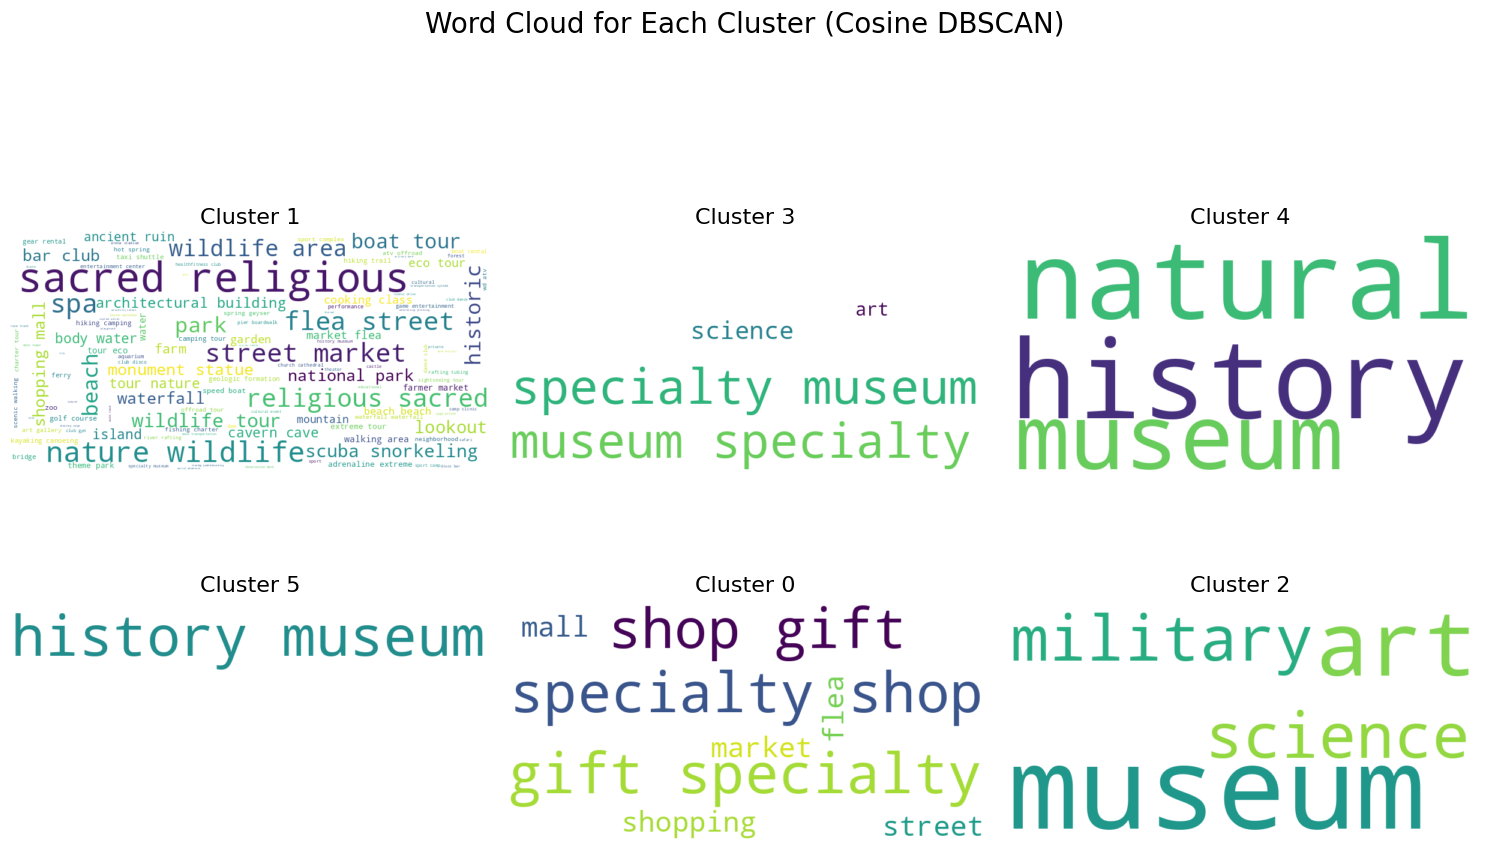

In [129]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

# Plot Word Clouds
num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster (Cosine DBSCAN)", fontsize=20)

axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [130]:
import plotly.express as px
from sklearn.manifold import TSNE

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=42)  # Adjust perplexity based on data size
reduced_embeddings = tsne.fit_transform(tag_embeddings)

# Create DataFrame for visualization
df = pd.DataFrame(reduced_embeddings, columns=["t-SNE Component 1", "t-SNE Component 2"])
df["Cluster"] = optimized_labels

# Plot using Plotly
fig = px.scatter(df, x="t-SNE Component 1", y="t-SNE Component 2", color=df["Cluster"].astype(str),
                 title="t-SNE Projection of Tag Clusters (Plotly)",
                 color_continuous_scale="viridis")

fig.show()
